In [2]:
import pandas as pd

df = pd.read_csv("data/aqi_data.csv", encoding="latin1")

df.head()

C:\Users\Jahnavi\AppData\Local\Temp\ipykernel_18084\3120037495.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/aqi_data.csv", encoding="latin1")


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152.0,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151.0,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


In [3]:
df.shape

(435742, 13)

In [4]:
df.isnull().sum()

stn_code                       144077
sampling_date                       3
state                               0
location                            3
agency                         149481
type                             5393
so2                             34646
no2                             16233
rspm                            40222
spm                            237387
location_monitoring_station     27491
pm2_5                          426428
date                                7
dtype: int64

In [5]:
df.describe()

,so2,no2,rspm,spm,pm2_5
count,401096.000000,419509.000000,395520.000000,198355.000000,9314.000000
mean,10.829414,25.809623,108.832784,220.783480,40.791467
std,11.177187,18.503086,74.872430,151.395457,30.832525
min,0.000000,0.000000,0.000000,0.000000,3.000000
25%,5.000000,14.000000,56.000000,111.000000,24.000000
50%,8.000000,22.000000,90.000000,187.000000,32.000000
75%,13.700000,32.200000,142.000000,296.000000,46.000000
max,909.000000,876.000000,6307.033333,3380.000000,504.000000


In [6]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435742 entries, 0 to 435741
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   stn_code                     291665 non-null  object        
 1   sampling_date                435739 non-null  object        
 2   state                        435742 non-null  object        
 3   location                     435739 non-null  object        
 4   agency                       286261 non-null  object        
 5   type                         430349 non-null  object        
 6   so2                          401096 non-null  float64       
 7   no2                          419509 non-null  float64       
 8   rspm                         395520 non-null  float64       
 9   spm                          198355 non-null  float64       
 10  location_monitoring_station  408251 non-null  object        
 11  pm2_5                     

In [7]:
df = df[['state','location','so2','no2','rspm','pm2_5','date']]

In [8]:
df = df.dropna(subset=['so2','no2','rspm','pm2_5'], how='all')

In [9]:
df.head()
df.shape

(431516, 7)

In [10]:
df['date'] = pd.to_datetime(df['date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 431516 entries, 0 to 435738
Data columns (total 7 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   state     431516 non-null  object        
 1   location  431516 non-null  object        
 2   so2       401096 non-null  float64       
 3   no2       419509 non-null  float64       
 4   rspm      395520 non-null  float64       
 5   pm2_5     9314 non-null    float64       
 6   date      431512 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 26.3+ MB


In [11]:
df = df[['state','location','so2','no2','rspm','pm2_5','date']]
df.head()

,state,location,so2,no2,rspm,pm2_5,date
0,Andhra Pradesh,Hyderabad,4.8,17.4,NaN,NaN,1990-02-01
1,Andhra Pradesh,Hyderabad,3.1,7.0,NaN,NaN,1990-02-01
2,Andhra Pradesh,Hyderabad,6.2,28.5,NaN,NaN,1990-02-01
3,Andhra Pradesh,Hyderabad,6.3,14.7,NaN,NaN,1990-03-01
4,Andhra Pradesh,Hyderabad,4.7,7.5,NaN,NaN,1990-03-01


In [12]:
df.shape

(431516, 7)

In [13]:
(df.isnull().sum() / len(df)) * 100

state        0.000000
location     0.000000
so2          7.049565
no2          2.782516
rspm         8.341753
pm2_5       97.841563
date         0.000927
dtype: float64

In [14]:
df = df.dropna(subset=['so2','no2','rspm','pm2_5'], how='all')
df.shape

(431516, 7)

In [15]:
df['so2'].fillna(df['so2'].median(), inplace=True)
df['no2'].fillna(df['no2'].median(), inplace=True)
df['rspm'].fillna(df['rspm'].median(), inplace=True)
df['pm2_5'].fillna(df['pm2_5'].median(), inplace=True)

C:\Users\Jahnavi\AppData\Local\Temp\ipykernel_18084\2268950175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['so2'].fillna(df['so2'].median(), inplace=True)
C:\Users\Jahnavi\AppData\Local\Temp\ipykernel_18084\2268950175.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

In [16]:
df.isnull().sum()

state       0
location    0
so2         0
no2         0
rspm        0
pm2_5       0
date        4
dtype: int64

In [17]:
df['AQI'] = (df['so2'] + df['no2'] + df['rspm'] + df['pm2_5']) / 4
df.head()

,state,location,so2,no2,rspm,pm2_5,date,AQI
0,Andhra Pradesh,Hyderabad,4.8,17.4,90.0,32.0,1990-02-01,36.050
1,Andhra Pradesh,Hyderabad,3.1,7.0,90.0,32.0,1990-02-01,33.025
2,Andhra Pradesh,Hyderabad,6.2,28.5,90.0,32.0,1990-02-01,39.175
3,Andhra Pradesh,Hyderabad,6.3,14.7,90.0,32.0,1990-03-01,35.750
4,Andhra Pradesh,Hyderabad,4.7,7.5,90.0,32.0,1990-03-01,33.550


In [18]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 200:
        return "Poor"
    else:
        return "Very Poor"

In [19]:
df['AQI_Category'] = df['AQI'].apply(categorize_aqi)
df.head()

,state,location,so2,no2,rspm,pm2_5,date,AQI,AQI_Category
0,Andhra Pradesh,Hyderabad,4.8,17.4,90.0,32.0,1990-02-01,36.050,Good
1,Andhra Pradesh,Hyderabad,3.1,7.0,90.0,32.0,1990-02-01,33.025,Good
2,Andhra Pradesh,Hyderabad,6.2,28.5,90.0,32.0,1990-02-01,39.175,Good
3,Andhra Pradesh,Hyderabad,6.3,14.7,90.0,32.0,1990-03-01,35.750,Good
4,Andhra Pradesh,Hyderabad,4.7,7.5,90.0,32.0,1990-03-01,33.550,Good


In [20]:
df['AQI_Category'].value_counts()

AQI_Category
Good         306430
Moderate     116565
Poor           8412
Very Poor       109
Name: count, dtype: int64

In [21]:
df.shape

(431516, 9)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

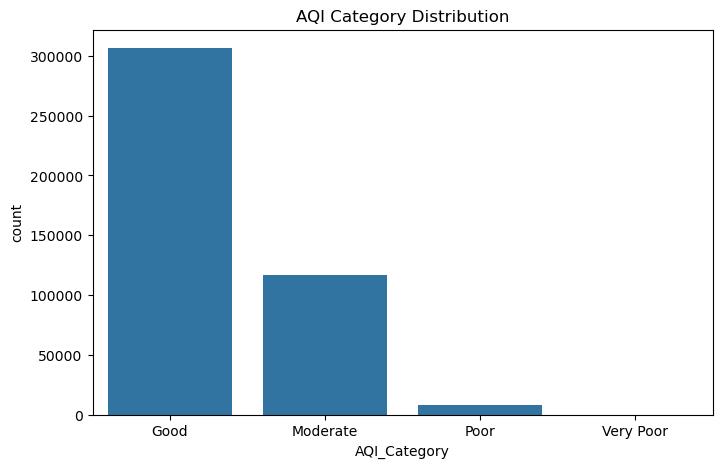

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(x='AQI_Category', data=df)
plt.title("AQI Category Distribution")
plt.show()

In [24]:
df['Year'] = df['date'].dt.year
df.head()

,state,location,so2,no2,rspm,pm2_5,date,AQI,AQI_Category,Year
0,Andhra Pradesh,Hyderabad,4.8,17.4,90.0,32.0,1990-02-01,36.050,Good,1990.0
1,Andhra Pradesh,Hyderabad,3.1,7.0,90.0,32.0,1990-02-01,33.025,Good,1990.0
2,Andhra Pradesh,Hyderabad,6.2,28.5,90.0,32.0,1990-02-01,39.175,Good,1990.0
3,Andhra Pradesh,Hyderabad,6.3,14.7,90.0,32.0,1990-03-01,35.750,Good,1990.0
4,Andhra Pradesh,Hyderabad,4.7,7.5,90.0,32.0,1990-03-01,33.550,Good,1990.0


In [25]:
yearly_aqi = df.groupby('Year')['AQI'].mean()
yearly_aqi.head()

Year
1987.0    43.229300
1988.0    43.669460
1989.0    42.354853
1990.0    41.291769
1991.0    41.310940
Name: AQI, dtype: float64

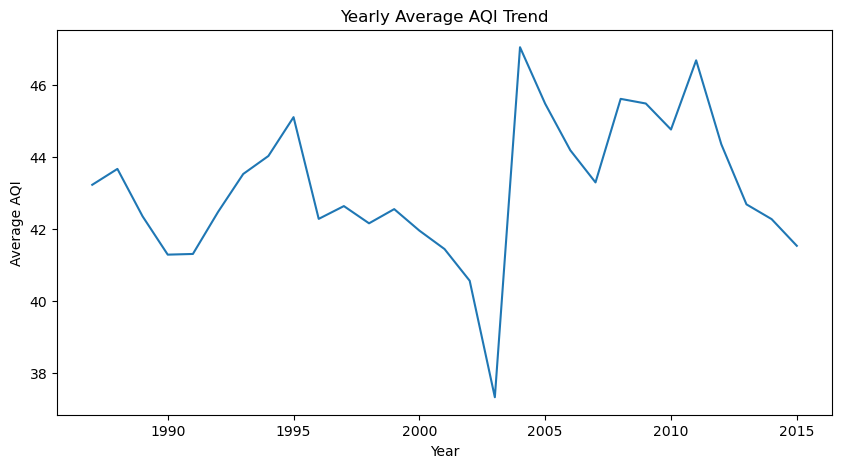

In [26]:
plt.figure(figsize=(10,5))
yearly_aqi.plot()
plt.title("Yearly Average AQI Trend")
plt.xlabel("Year")
plt.ylabel("Average AQI")
plt.show()

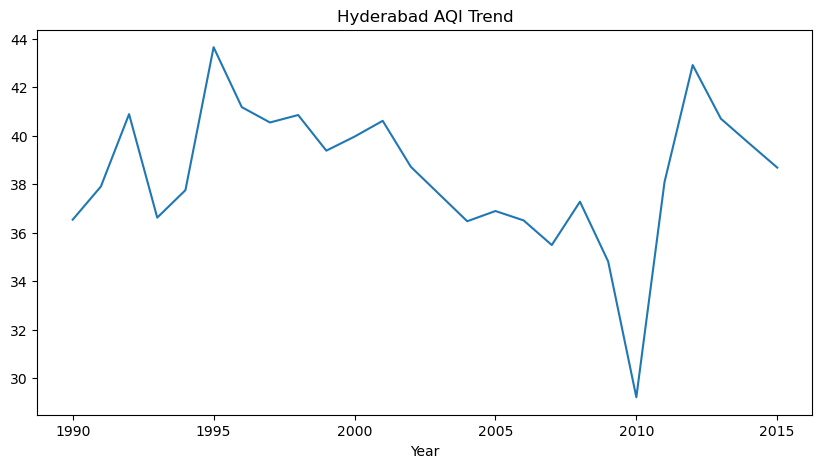

In [27]:
hyd = df[df['location'] == 'Hyderabad']
hyd_yearly = hyd.groupby('Year')['AQI'].mean()

plt.figure(figsize=(10,5))
hyd_yearly.plot()
plt.title("Hyderabad AQI Trend")
plt.show()